In [ ]:
# basic imports
from google.colab import drive
import zipfile  # ✅ Needed to unzip
import os

# Mount Drive
drive.mount('/content/drive')

# Unzip dataset
# zip_path = '/content/drive/My Drive/SMOKE_zip.zip'
# extract_path = '/content/drive/My Drive/fog_dataset1'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("✅ Dataset extracted to:", extract_path)


Mounted at /content/drive


In [ ]:
# laoding data in pytorch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import os

# Paths (from extracted folder)
hazy_dir = '/content/drive/My Drive/fog_dataset1/train/hazy'
clean_dir = '/content/drive/My Drive/fog_dataset1/train/clean'

# Dataset Class
class PairedDataset(Dataset):
    def __init__(self, hazy_dir, clean_dir, transform=None):
        self.hazy_dir = hazy_dir
        self.clean_dir = clean_dir
        self.filenames = sorted(os.listdir(hazy_dir))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        hazy_path = os.path.join(self.hazy_dir, self.filenames[idx])
        clean_path = os.path.join(self.clean_dir, self.filenames[idx])
        hazy_img = Image.open(hazy_path).convert("RGB")
        clean_img = Image.open(clean_path).convert("RGB")
        if self.transform:
            hazy_img = self.transform(hazy_img)
            clean_img = self.transform(clean_img)
        return hazy_img, clean_img

# Transforms: Resize to 256x256, convert to tensor, normalize
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

# Dataloader
dataset = PairedDataset(hazy_dir, clean_dir, transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Test one batch
sample_batch = next(iter(dataloader))
print("✅ Dataloader loaded successfully!")
print("Hazy batch shape:", sample_batch[0].shape)
print("Clean batch shape:", sample_batch[1].shape)


✅ Dataloader loaded successfully!
Hazy batch shape: torch.Size([4, 3, 256, 256])
Clean batch shape: torch.Size([4, 3, 256, 256])


In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F

# New Building Block: The Attention Gate
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        # Convolution for the gating signal (from the decoder)
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Convolution for the skip connection signal (from the encoder)
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Final convolution to produce the attention map
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Process gating signal and skip connection
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # Combine them and apply ReLU
        psi = self.relu(g1 + x1)

        # Generate the 1-channel attention map
        psi = self.psi(psi)

        # Multiply the original skip connection by the attention map to apply focus
        return x * psi

# The New Generator with Attention Gates
class AttentionUNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()

        # Re-using the same helper functions from your original code
        def down(in_f, out_f, normalize=True):
            layers = [nn.Conv2d(in_f, out_f, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2))
            return nn.Sequential(*layers)

        def up(in_f, out_f, dropout=False):
            layers = [nn.ConvTranspose2d(in_f, out_f, 4, 2, 1, bias=False),
                      nn.BatchNorm2d(out_f),
                      nn.ReLU()]
            if dropout:
                layers.append(nn.Dropout(0.5))
            return nn.Sequential(*layers)

        # ---- ENCODER (Downsampling) ----
        self.down1 = down(in_channels, features, normalize=False)
        self.down2 = down(features, features * 2)
        self.down3 = down(features * 2, features * 4)
        self.down4 = down(features * 4, features * 8)
        self.down5 = down(features * 8, features * 8)
        self.down6 = down(features * 8, features * 8)

        # ---- DECODER (Upsampling) ----
        self.up1 = up(features * 8, features * 8, dropout=True)
        self.up2 = up(features * 16, features * 8, dropout=True)
        self.up3 = up(features * 16, features * 4)
        self.up4 = up(features * 8, features * 2)
        self.up5 = up(features * 4, features)

# ---- ATTENTION GATES (Corrected Code) ----
        self.Att5 = AttentionGate(F_g=features*8, F_l=features*8, F_int=features*4)
        self.Att4 = AttentionGate(F_g=features*8, F_l=features*8, F_int=features*4)
        self.Att3 = AttentionGate(F_g=features*4, F_l=features*4, F_int=features*2)
        self.Att2 = AttentionGate(F_g=features*2, F_l=features*2, F_int=features)

        # ---- FINAL LAYER ----
        self.final = nn.Sequential(
            nn.ConvTranspose2d(features * 2, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder Path
        d1 = self.down1(x)   # features
        d2 = self.down2(d1)  # features * 2
        d3 = self.down3(d2)  # features * 4
        d4 = self.down4(d3)  # features * 8
        d5 = self.down5(d4)  # features * 8
        d6 = self.down6(d5)  # features * 8 (bottleneck)

        # Decoder Path with Attention Gates
        u1 = self.up1(d6)
        # Apply attention to the skip connection d5 using gating signal u1
        att5 = self.Att5(g=u1, x=d5)
        u2 = self.up2(torch.cat([u1, att5], dim=1))

        att4 = self.Att4(g=u2, x=d4)
        u3 = self.up3(torch.cat([u2, att4], dim=1))

        att3 = self.Att3(g=u3, x=d3)
        u4 = self.up4(torch.cat([u3, att3], dim=1))

        att2 = self.Att2(g=u4, x=d2)
        u5 = self.up5(torch.cat([u4, att2], dim=1))

        # Final output (d1 is the first skip connection)
        return self.final(torch.cat([u5, d1], dim=1))

In [ ]:
# Check if generator runs
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Create generator
netG = AttentionUNetGenerator().to(device)

# Get one batch from dataloader
hazy_sample, _ = next(iter(dataloader))
hazy_sample = hazy_sample.to(device)

# Run through generator
with torch.no_grad():
    output_sample = netG(hazy_sample)

print("✅ Generator output shape:", output_sample.shape)


✅ Generator output shape: torch.Size([4, 3, 256, 256])


In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=6):  # hazy (3) + clean (3)
        super().__init__()

        def block(in_f, out_f, normalize=True):
            layers = [nn.Conv2d(in_f, out_f, 4, 2, 1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1)  # output patch score
        )

    def forward(self, input_img, target_img):
        x = torch.cat([input_img, target_img], dim=1)  # concatenate along channels
        return self.model(x)


In [ ]:
import torch.optim as optim
import torchvision.utils as vutils
import os
from tqdm import tqdm

# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G = AttentionUNetGenerator().to(device)
D = PatchDiscriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))

# Create results folder
os.makedirs('pix2pix_results', exist_ok=True)

# Training loop
num_epochs = 100

for epoch in range(num_epochs):
    G.train()
    D.train()
    loop = tqdm(dataloader, leave=False)
    for i, (hazy, clean) in enumerate(loop):
        hazy = hazy.to(device)
        clean = clean.to(device)

        # ---- Train Discriminator ----
        fake_clean = G(hazy)
        D_real = D(hazy, clean)
        D_fake = D(hazy, fake_clean.detach())
        loss_D_real = criterion_GAN(D_real, torch.ones_like(D_real))
        loss_D_fake = criterion_GAN(D_fake, torch.zeros_like(D_fake))
        loss_D = (loss_D_real + loss_D_fake) * 0.5

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        D_fake_for_G = D(hazy, fake_clean)
        loss_G_GAN = criterion_GAN(D_fake_for_G, torch.ones_like(D_fake_for_G))
        loss_G_L1 = criterion_L1(fake_clean, clean) * 100
        loss_G = loss_G_GAN + loss_G_L1

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(D_Loss=loss_D.item(), G_Loss=loss_G.item())

    # ---- Save generated samples after each epoch ----
    vutils.save_image(fake_clean[:4], f"pix2pix_results/epoch_{epoch+1:03}.png", normalize=True)

print("✅ Training complete.")


✅ Training complete.


### RAN FOR 2 hours and close to 43 miniutes on cpu
### hardly 7 minutes on gpu

In [ ]:
import torchvision.transforms.functional as TF
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np

G.eval()  # Evaluation mode

total_ssim = 0
total_psnr = 0
count = 0

# Loop through entire dataset
for hazy, clean in dataloader:
    hazy = hazy.to(device)
    clean = clean.to(device)

    with torch.no_grad():
        fake_clean = G(hazy)

    # Denormalize
    fake_clean = fake_clean * 0.5 + 0.5
    clean = clean * 0.5 + 0.5

    for i in range(hazy.size(0)):
        fake_img = fake_clean[i].detach().cpu().permute(1, 2, 0).numpy()
        real_img = clean[i].detach().cpu().permute(1, 2, 0).numpy()

        # Convert to [0, 255]
        fake_img_uint8 = (fake_img * 255).astype(np.uint8)
        real_img_uint8 = (real_img * 255).astype(np.uint8)

        # SSIM and PSNR
        ssim_val = ssim(real_img_uint8, fake_img_uint8, channel_axis=-1)
        psnr_val = psnr(real_img_uint8, fake_img_uint8)

        total_ssim += ssim_val
        total_psnr += psnr_val
        count += 1

# Final results
avg_ssim = total_ssim / count
avg_psnr = total_psnr / count

print(f"\n✅ Model Evaluation Completed")
print(f"🔸 Average SSIM: {avg_ssim:.4f}")
print(f"🔸 Average PSNR: {avg_psnr:.2f} dB")



✅ Model Evaluation Completed
🔸 Average SSIM: 0.7874
🔸 Average PSNR: 25.30 dB


/tmp/ipython-input-3582795184.py:57: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3582795184.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3582795184.py:57: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

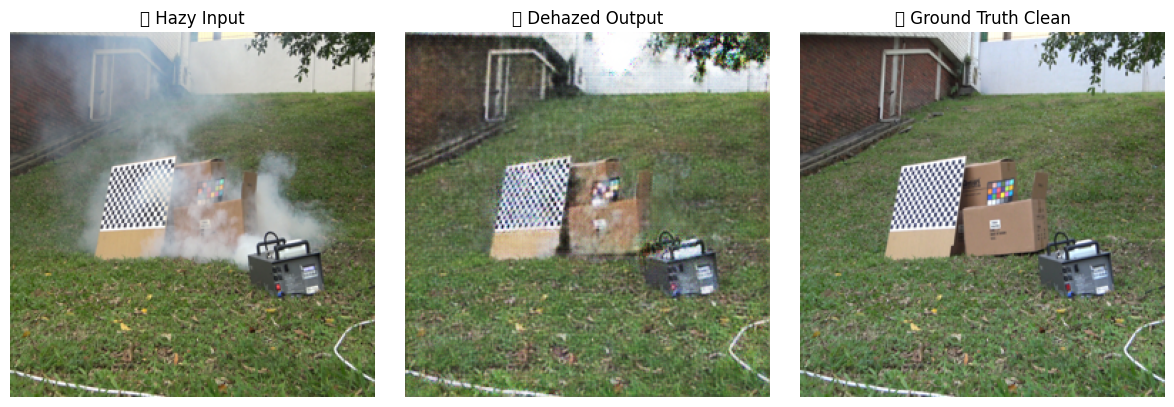

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
import torch

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G.eval()

# 🔁 Choose a hazy image file from your dataset
img_name = '105.png'  # or any from your dataset
hazy_path = f'/content/drive/My Drive/fog_dataset1/train/hazy/{img_name}'
clean_path = f'/content/drive/My Drive/fog_dataset1/train/clean/{img_name}'

# 🖼 Load images
hazy_img = Image.open(hazy_path).convert('RGB')
clean_img = Image.open(clean_path).convert('RGB')

# 🔁 Transform input
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])
input_tensor = transform(hazy_img).unsqueeze(0).to(device)

# 🔮 Predict clean image
with torch.no_grad():
    output = G(input_tensor).squeeze().cpu()

# 🔄 Denormalize output
output = (output * 0.5) + 0.5
output = output.permute(1, 2, 0).numpy()

# 🔁 Resize originals to 256x256 for display
hazy_img = hazy_img.resize((256, 256))
clean_img = clean_img.resize((256, 256))

# 📊 Show all images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(hazy_img)
plt.title("🔸 Hazy Input")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(output)
plt.title("✅ Dehazed Output")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clean_img)
plt.title("🎯 Ground Truth Clean")
plt.axis('off')

plt.tight_layout()
plt.show()


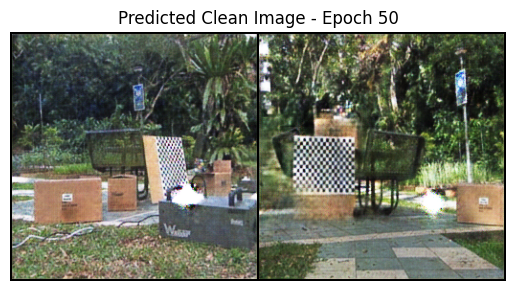

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Change the epoch number to see other outputs
img_path = '/content/pix2pix_results/epoch_050.png'

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Clean Image - Epoch 50")
plt.show()


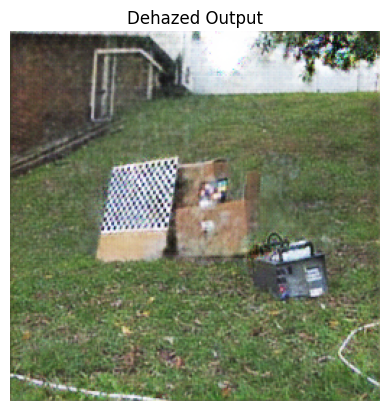

In [ ]:
G.eval()  # Put generator in eval mode

# Load hazy test image
test_img = Image.open("/content/drive/My Drive/fog_dataset1/train/hazy/105.png").convert("RGB")

# Preprocess
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])
input_tensor = transform(test_img).unsqueeze(0).to(device)

# Generate clean image
with torch.no_grad():
    output = G(input_tensor)

# Display output
output_img = output.squeeze().detach().cpu()
output_img = (output_img * 0.5) + 0.5  # De-normalize

plt.imshow(output_img.permute(1, 2, 0))
plt.axis('off')
plt.title("Dehazed Output")
plt.show()
